# Intelligent Threat Detection: Multi-Domain Airborne and Ground Military Object Recognition
This is our complete machine learning pipeline. First, we will do some Exploratory Data Analysis (EDA) to see what we are working with. Then, we will build a baseline Convolutional Neural Network (CNN) to prove that detecting these objects is not a trivial task. Finally, we will train an advanced YOLOv8 model on our fused dataset to hit our target metrics like a high F1 Score and mean Average Precision.

In [1]:
import os
import shutil
import random
import math
import glob
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from ultralytics import YOLO

# plt.style.use('seaborn-whitegrid')
seed = 67
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


## 1. Exploratory Data Analysis (EDA) & Data Fusion
We need to combine our AOD-4 and Military datasets into one big dataset. We will also split the data into training and validation sets so we can test the model fairly.

In [ ]:
def setup_directories(base_path):
    dirs = ['images/train', 'images/val', 'labels/train', 'labels/val']
    for d in dirs:
        os.makedirs(os.path.join(base_path, d), exist_ok=True)

if os.path.exists('fused_dataset'):
    shutil.rmtree('fused_dataset')

setup_directories('fused_dataset')

sources = [
    ('raw_data/aod_data/Images/train', 'raw_data/aod_data/Annotations/YOLOv8 format/train/labels', 'train'),
    ('raw_data/aod_data/Images/valid', 'raw_data/aod_data/Annotations/YOLOv8 format/valid/labels', 'val'),
    ('raw_data/aod_data/Images/test', 'raw_data/aod_data/Annotations/YOLOv8 format/test/labels', 'val'),
    ('raw_data/mil_data/train/images', 'raw_data/mil_data/train/labels', 'train'),
    ('raw_data/mil_data/valid/images', 'raw_data/mil_data/valid/labels', 'val'),
    ('raw_data/mil_data/test/images', 'raw_data/mil_data/test/labels', 'val'),
]


def collect_labeled_images(images_dir, labels_dir):
    images = sorted([f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.png'))])
    labeled = []
    missing = []
    for img in images:
        label_file = os.path.splitext(img)[0] + '.txt'
        if os.path.exists(os.path.join(labels_dir, label_file)):
            labeled.append(img)
        else:
            missing.append(img)
    return labeled, missing


def copy_labeled_split(source_img_dir, source_lbl_dir, target_split):
    target_img_dir = os.path.join('fused_dataset', 'images', target_split)
    target_lbl_dir = os.path.join('fused_dataset', 'labels', target_split)
    os.makedirs(target_img_dir, exist_ok=True)
    os.makedirs(target_lbl_dir, exist_ok=True)

    labeled_images, skipped_images = collect_labeled_images(source_img_dir, source_lbl_dir)
    for img in labeled_images:
        shutil.copy(os.path.join(source_img_dir, img), os.path.join(target_img_dir, img))
        label_name = os.path.splitext(img)[0] + '.txt'
        shutil.copy(os.path.join(source_lbl_dir, label_name), os.path.join(target_lbl_dir, label_name))
    return len(labeled_images), len(skipped_images)


def count_dataset(path):
    stats = {}
    for split in ['train', 'val']:
        stats[split] = {
            'images': len(glob.glob(os.path.join(path, 'images', split, '*.jpg'))) + len(glob.glob(os.path.join(path, 'images', split, '*.png'))),
            'labels': len(glob.glob(os.path.join(path, 'labels', split, '*.txt'))),
        }
    return stats


for img_dir, lbl_dir, split in sources:
    if not os.path.isdir(img_dir) or not os.path.isdir(lbl_dir):
        print(f'Skipping missing source: {img_dir} or {lbl_dir}')
        continue
    copied, skipped = copy_labeled_split(img_dir, lbl_dir, split)
    print(f'Copied {copied} labeled images from {img_dir} into fused_dataset/{split} (skipped {skipped} images without labels)')

fused_counts = count_dataset('fused_dataset')
print('\nFused dataset counts:')
for split, info in fused_counts.items():
    print(f"  {split}: {info['images']} images, {info['labels']} labels")


## 2. Data augmentation and DataLoader for fused_dataset

In [2]:
# --- Data augmentation and DataLoader for fused_dataset
class YoloDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transforms=None):
        self.images = sorted([f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.png'))])
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transforms = transforms

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.images_dir, img_name)
        img = Image.open(img_path).convert('RGB')
        if self.transforms:
            img = self.transforms(img)
        lbl_path = os.path.join(self.labels_dir, os.path.splitext(img_name)[0] + '.txt')
        boxes = []
        labels = []
        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        labels.append(int(float(parts[0])))
                        boxes.append([float(x) for x in parts[1:5]])
        target = {'boxes': boxes, 'labels': labels, 'image_id': idx}
        return img, target

train_transforms = transforms.Compose([
    transforms.Resize((640, 640)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize((640, 640)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ds = YoloDataset('fused_dataset/images/train', 'fused_dataset/labels/train', transforms=train_transforms)
val_ds = YoloDataset('fused_dataset/images/val', 'fused_dataset/labels/val', transforms=val_transforms)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=4, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=4, pin_memory=torch.cuda.is_available())

print('Train samples:', len(train_ds), 'Val samples:', len(val_ds))
sample_img, sample_target = train_ds[0]
print('Sample image shape:', sample_img.shape)
print('Sample target keys:', sample_target.keys())

Train samples: 21352 Val samples: 9149
Sample image shape: torch.Size([3, 640, 640])
Sample target keys: dict_keys(['boxes', 'labels', 'image_id'])


## 3. Detection Baseline with Faster R-CNN
We train a torchvision `fasterrcnn_resnet50_fpn` detector on the same fused dataset to establish a strong object detection baseline before fine-tuning YOLOv8.

In [3]:
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def xywh_to_xyxy(box, width, height):
    cx, cy, w, h = box
    x1 = (cx - w / 2) * width
    y1 = (cy - h / 2) * height
    x2 = (cx + w / 2) * width
    y2 = (cy + h / 2) * height
    return [x1, y1, x2, y2]

class FasterRCNNDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transforms=None):
        self.images = sorted([f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.png'))])
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transforms = transforms

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.images_dir, img_name)
        img = Image.open(img_path).convert('RGB')
        
        img = img.resize((640, 640))
        w, h = 640, 640

        lbl_path = os.path.join(self.labels_dir, os.path.splitext(img_name)[0] + '.txt')
        boxes, labels = [], []
        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        labels.append(int(float(parts[0])) + 1)
                        boxes.append(xywh_to_xyxy([float(x) for x in parts[1:5]], w, h))

        if len(boxes) == 0:
            boxes_tensor = torch.zeros((0, 4), dtype=torch.float32)
            labels_tensor = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes_tensor = torch.tensor(boxes, dtype=torch.float32)
            labels_tensor = torch.tensor(labels, dtype=torch.int64)

        target = {
            'boxes': boxes_tensor,
            'labels': labels_tensor,
            'image_id': torch.tensor([idx]),
        }

        if self.transforms:
            img = self.transforms(img)

        return img, target

def collate_fn(batch):
    return tuple(zip(*batch))

frcnn_transforms = transforms.Compose([
    transforms.ToTensor(),
])

frcnn_train_dataset = FasterRCNNDataset('fused_dataset/images/train', 'fused_dataset/labels/train', transforms=frcnn_transforms)
frcnn_val_dataset = FasterRCNNDataset('fused_dataset/images/val', 'fused_dataset/labels/val', transforms=frcnn_transforms)

frcnn_train_loader = DataLoader(frcnn_train_dataset, batch_size=16, shuffle=True, num_workers=0, collate_fn=collate_fn, pin_memory=False)
frcnn_val_loader = DataLoader(frcnn_val_dataset, batch_size=16, shuffle=False, num_workers=0, collate_fn=collate_fn, pin_memory=False)

try:
    model_frcnn = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')
except TypeError:
    model_frcnn = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

in_features = model_frcnn.roi_heads.box_predictor.cls_score.in_features
model_frcnn.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes=8)
model_frcnn.to(device)

optimizer_frcnn = optim.SGD([p for p in model_frcnn.parameters() if p.requires_grad], lr=0.005, momentum=0.9, weight_decay=0.0005)
scheduler_frcnn = optim.lr_scheduler.StepLR(optimizer_frcnn, step_size=3, gamma=0.1)

num_epochs = 3

print('Faster R-CNN model ready. Train with the next cell to compare against YOLO.')

def train_frcnn(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0
    
    # Simple step tracking instead of a nested progress bar widget
    total_batches = len(loader)
    
    for batch_idx, (images, targets) in enumerate(loader):
        valid_indices = [i for i, t in enumerate(targets) if t['boxes'].shape[0] > 0]
        if not valid_indices:
            continue
            
        images = [images[i].to(device) for i in valid_indices]
        targets = [{k: v.to(device) for k, v in targets[i].items() if k != 'image_id'} for i in valid_indices]
        
        loss_dict = model(images, targets)
        loss = sum(loss for loss in loss_dict.values())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # Explicit print statement every 20 batches to show live proof of training
        if batch_idx % 1 == 0:
            print(f"   ↳ Processing Batch {batch_idx}/{total_batches} | Current Loss: {loss.item():.4f}", end="\r")
            
    print() # Clear the line after epoch completes
    return running_loss / total_batches

def evaluate_frcnn(model, loader, device, iou_threshold=0.5, score_thresh=0.3):
    model.eval()
    total_tp = total_fp = total_fn = 0
    total_gt = 0
    val_bar = tqdm(loader, desc="Evaluating", leave=False)
    with torch.no_grad():
        for images, targets in val_bar:
            images = [img.to(device) for img in images]
            outputs = model(images)
            for output, target in zip(outputs, targets):
                gt_boxes = target['boxes'].cpu()
                gt_labels = target['labels'].cpu()
                total_gt += len(gt_labels)

                if len(gt_labels) == 0:
                    total_fp += len(output['boxes'])
                    continue

                selected = output['scores'] >= score_thresh
                pred_boxes = output['boxes'][selected].cpu()
                pred_labels = output['labels'][selected].cpu()

                matches = torch.zeros(len(gt_boxes), dtype=torch.bool)
                for pb, pl in zip(pred_boxes, pred_labels):
                    ious = torchvision.ops.box_iou(pb.unsqueeze(0), gt_boxes).squeeze(0)
                    same_class = gt_labels == pl
                    if same_class.any():
                        ious = ious * same_class
                        best_iou, best_idx = ious.max(0)
                        if best_iou >= iou_threshold and not matches[best_idx]:
                            total_tp += 1
                            matches[best_idx] = True
                        else:
                            total_fp += 1
                    else:
                        total_fp += 1

                total_fn += (~matches).sum().item()

    precision = total_tp / (total_tp + total_fp + 1e-9)
    recall = total_tp / (total_tp + total_fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    return {
        'tp': total_tp,
        'fp': total_fp,
        'fn': total_fn,
        'gt': total_gt,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }

# Too many poitns to plot, it takes up all of my RAM
# def plot_rcnn_sample(model, dataset, device, count=2):
#     model.eval()
#     for i in range(min(count, len(dataset))):
#         img, target = dataset[i]
#         with torch.no_grad():
#             preds = model([img.to(device)])[0]
#         img_np = img.mul(255).permute(1, 2, 0).byte().cpu().numpy()
#         img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
#         for box, score, label in zip(preds['boxes'], preds['scores'], preds['labels']):
#             if score < 0.3:
#                 continue
#             x1, y1, x2, y2 = map(int, box.cpu().numpy())
#             cv2.rectangle(img_bgr, (x1, y1), (x2, y2), (16, 160, 16), 2)
#             cv2.putText(img_bgr, f'{label.item()-1}:{score:.2f}', (x1, y1 - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (16, 160, 16), 1)
#         plt.figure(figsize=(10, 6))
#         plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
#         plt.axis('off')
#         plt.title(f'Faster R-CNN prediction sample {i}')
#         plt.show()

d:\prj\threat_detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Faster R-CNN model ready. Train with the next cell to compare against YOLO.


In [4]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

frcnn_transforms = transforms.Compose([
    transforms.Resize((640, 640)),
    transforms.ToTensor(),
])

frcnn_train_dataset = FasterRCNNDataset('fused_dataset/images/train', 'fused_dataset/labels/train', transforms=frcnn_transforms)
frcnn_val_dataset = FasterRCNNDataset('fused_dataset/images/val', 'fused_dataset/labels/val', transforms=frcnn_transforms)

frcnn_train_loader = DataLoader(
    frcnn_train_dataset, 
    batch_size=8,
    shuffle=True, 
    num_workers=0, 
    collate_fn=collate_fn, 
    pin_memory=False
)

frcnn_val_loader = DataLoader(
    frcnn_val_dataset, 
    batch_size=8, 
    shuffle=False, 
    num_workers=0, 
    collate_fn=collate_fn, 
    pin_memory=False
)

print("Data loaders updated safely!")

Data loaders updated safely!


In [ ]:
from tqdm.auto import tqdm

def train_frcnn_epochs(model, train_loader, optimizer, scheduler, device, epochs=3):
    history = []
    epoch_bar = tqdm(range(1, epochs + 1), desc="Training Epochs")
    for epoch in epoch_bar:
        train_loss = train_frcnn(model, train_loader, optimizer, device)
        scheduler.step()
        epoch_bar.set_postfix(last_epoch_loss=f"{train_loss:.4f}")
        print(f'Epoch {epoch}/{epochs} - Faster R-CNN training loss: {train_loss:.4f}')
        history.append(train_loss)
    return history

frcnn_history = train_frcnn_epochs(model_frcnn, frcnn_train_loader, optimizer_frcnn, scheduler_frcnn, device, epochs=num_epochs)

Training Epochs:   0%|          | 0/3 [00:00<?, ?it/s]

Training Epochs:  100%|█████████| 3/3 [4:01:53<8:03:46, 14513.31s/it, last_epoch_loss=0.1760]

   ↳ Processing Batch 2668/2669 | Current Loss: 0.1653
Epoch 3/3 - Faster R-CNN training loss: 0.1760


In [ ]:
print("\nRunning evaluation on validation set...")
frcnn_metrics = evaluate_frcnn(model_frcnn, frcnn_val_loader, device, iou_threshold=0.5, score_thresh=0.3)

print('Faster R-CNN validation metrics:')
print(f"  GT boxes: {frcnn_metrics['gt']}")
print(f"  TP: {frcnn_metrics['tp']}, FP: {frcnn_metrics['fp']}, FN: {frcnn_metrics['fn']}")
print(f"  Precision: {frcnn_metrics['precision']:.4f}")
print(f"  Recall:    {frcnn_metrics['recall']:.4f}")
print(f"  F1 Score:  {frcnn_metrics['f1']:.4f}")

# plot_rcnn_sample(model_frcnn, frcnn_val_dataset, device, count=2)

Running evaluation on validation set...
Faster R-CNN validation metrics:
  GT boxes: 12540
  TP: 7248, FP: 3152, FN: 5292
  Precision: 0.6969
  Recall:    0.5780
  F1 Score:  0.6319


We start the training. We set the image size to 640x640 to catch small objects, and we run it for 100 epochs to make sure it learns the synthetic GTA 5 data and the real-world data perfectly.

In [6]:
# --- YOLO training environment and data sanity checks
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA device count: {torch.cuda.device_count()}")
else:
    print("Running on CPU; training will be slower.")

print(f"Fused dataset directory exists: {os.path.exists('fused_dataset')}")
print(f"YAML config available: {os.path.exists('military_objects.yaml')}")
print(f"Train image count: {len(glob.glob('fused_dataset/images/train/*.jpg')) + len(glob.glob('fused_dataset/images/train/*.png'))}")
print(f"Val image count: {len(glob.glob('fused_dataset/images/val/*.jpg')) + len(glob.glob('fused_dataset/images/val/*.png'))}")

CUDA available: True
GPU: NVIDIA GeForce RTX 5060
CUDA device count: 1
Fused dataset directory exists: True
YAML config available: True
Train image count: 21352
Val image count: 9149


In [6]:
def train_yolo(model_name='yolov8n.pt', epochs=20, batch=16, imgsz=640, save_dir='runs/train'):
    device = 0 if torch.cuda.is_available() else 'cpu'
    print(f"Training YOLO model {model_name} on device={device}")
    model = YOLO(model_name)
    name = f"{os.path.splitext(model_name)[0]}_fine_tuned"
    out = model.train(
        data='military_objects.yaml',
        epochs=epochs,
        imgsz=imgsz,
        batch=batch,
        device=device,
        workers=4,
        patience=12,
        project=save_dir,
        name=name,
        save=True,
        cache=True,
        augment=True,
        optimizer='SGD',
        lr0=0.01,
        lrf=0.1,
        val=True,
    )
    return model, out

experiments = [
    # {'model': 'yolov8n.pt', 'epochs': 40, 'batch': 32},
    {'model': 'yolov8s.pt', 'epochs': 20, 'batch': 16},
]

trained_models = {}
train_logs = {}
for exp in experiments:
    print(f"Starting experiment: {exp['model']} epochs={exp['epochs']} batch={exp['batch']}")
    model, out = train_yolo(exp['model'], epochs=exp['epochs'], batch=exp['batch'])
    trained_models[exp['model']] = model
    train_logs[exp['model']] = out
    print(f"Finished experiment: {exp['model']}")

# Record best run summary
for model_name, out in train_logs.items():
    if hasattr(out, 'box') and hasattr(out.box, 'map50'):
        print(f"{model_name} final mAP@0.5: {out.box.map50:.4f}")
    else:
        print(f"{model_name} training output does not include map50 summary")


Starting experiment: yolov8s.pt epochs=20 batch=16
Training YOLO model yolov8s.pt on device=0
Ultralytics 8.4.69  Python-3.14.6 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5060, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=military_objects.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_fi

## 4. Evaluation and Metrics
After training, we have to check if we hit our success metrics from the proposal. We want to look at mAP@0.5, Precision, and Recall. We also apply Non-Maximum Suppression (NMS) to filter out bad boxes.

### Find and load automatically if the YOLO model is already trained

In [5]:
import os
import glob
from ultralytics import YOLO

def find_latest_best_weights(root_dir='runs'):
    search_pattern = os.path.join(root_dir, '**', 'weights', 'best.pt')
    paths = sorted(
        glob.glob(search_pattern, recursive=True),
        key=os.path.getmtime,
        reverse=True
    )
    return paths[0] if paths else None

best_weights_path = find_latest_best_weights()

if best_weights_path is None or not os.path.exists(best_weights_path):
    raise FileNotFoundError("Could not locate any fine-tuned 'best.pt' file in the workspace directory tree.")

print(f"Automatically located and loading weights from: {best_weights_path}")

trained_models = {
    'yolov8s.pt': YOLO(best_weights_path)
}

best_yolo_model = trained_models['yolov8s.pt']

Automatically located and loading weights from: runs\detect\runs\train\yolov8s_fine_tuned-6\weights\best.pt


In [10]:
# best_yolo_model = trained_models.get('yolov8s.pt', trained_models.get('yolov8n.pt', None))

if best_yolo_model is None:
    raise RuntimeError('No trained YOLO model found. Run the fine-tuning cell first.')

results = best_yolo_model.val(
    data='military_objects.yaml', 
    conf=0.25, 
    iou=0.45, 
    batch=1,          # Drop to 1 if 4 is still choking
    workers=0,        # Good choice, keeps everything in the main process
    cache=False,      # Good choice, prevents RAM caching
    
    # --- THE RAM SAVERS ---
    plots=False,      # CRITICAL: Matplotlib generation for val batches hogs massive memory
    save_json=False,  # Prevents saving massive coco-format JSONs to disk/RAM
    save_hybrid=False,# Do not save hybrid labels
    half=True,        # Use FP16 half-precision evaluation (slashes VRAM/RAM in half)
    device='cuda'     # Force CUDA if available, or 'cpu' to be explicit
)

# Calculate metrics safely
mp = results.box.mp
mr = results.box.mr
f1 = (2 * (mp * mr) / (mp + mr)) if (mp + mr) > 0 else 0

print(f"YOLOv8 final mAP@0.5: {results.box.map50:.4f}")
print(f"YOLOv8 final Precision: {mp:.4f}")
print(f"YOLOv8 final Recall: {mr:.4f}")
print(f"YOLOv8 final F1 Score: {f1:.4f}")

WARNING 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.4.69  Python-3.14.6 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5060, 8151MiB)
Model summary (fused): 73 layers, 11,128,293 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 9.96.0 MB/s, size: 77.9 KB)
val: Scanning D:\prj\threat_detection\fused_dataset\labels\val.cache... 9149 images, 181 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 9149/9149 1.5Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9149/9149 40.5it/s 3:460.1ss
                   all       9149      13286      0.924      0.886      0.879      0.594
              Airplane       2570       3861      0.916      0.902      0.897      0.651
            Helicopter       1365       2839      0.948      0.887      0.887      0.618
                 Drone       3020       3760      0.905      0.862      0.845      0.551
                  Bird      

## 5. Visualizing Predictions
Finally, let's run an image through the trained model and draw the bounding boxes to see our results in action.

Visualizing: fused_dataset/images/val\20190925_101846_1_1_080_jpg.rf.be9239b670f033fd8eea6d215a7232a5.jpg on device: cuda
Loading YOLO weights from: runs\detect\runs\train\yolov8s_fine_tuned-6\weights\best.pt


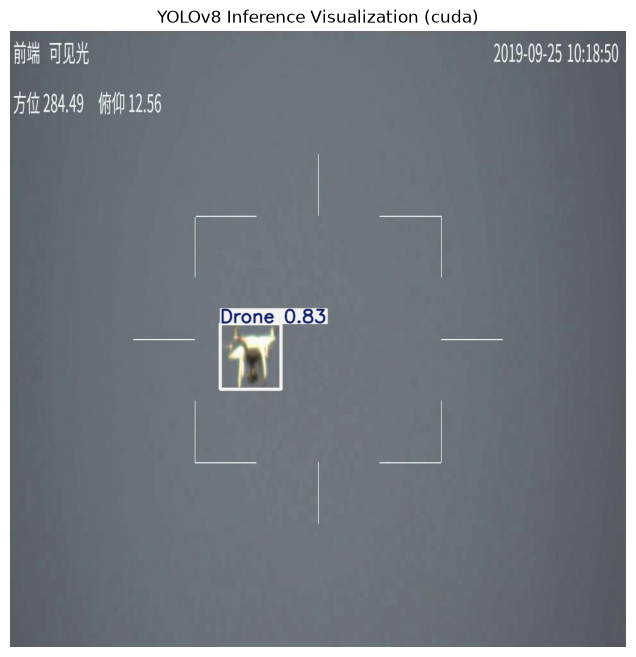

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

val_dir = 'fused_dataset/images/val'
val_images = sorted([f for f in os.listdir(val_dir) if f.lower().endswith(('.jpg', '.png'))])
if len(val_images) == 0:
    raise FileNotFoundError(f'No validation images found in {val_dir}')

sample_path = os.path.join(val_dir, val_images[10])
print('Visualizing:', sample_path, 'on device:', device)

# Prefer loading a fresh model from saved weights to avoid stale training-state issues.
def find_best_yolo_weights(root='runs'):
    paths = sorted(
        glob.glob(os.path.join(root, '**', 'weights', 'best.pt'), recursive=True),
        key=os.path.getmtime,
        reverse=True,
    )
    return paths[0] if paths else None

best_weights = find_best_yolo_weights('runs')
if best_weights and os.path.exists(best_weights):
    print('Loading YOLO weights from:', best_weights)
    yolo_model = YOLO(best_weights)
else:
    print('No saved best weights found, falling back to in-memory trained_models object')
    yolo_model = trained_models.get('yolov8s.pt', trained_models.get('yolov8n.pt', None))
    if yolo_model is None:
        raise RuntimeError('No trained model available. Run the fine-tuning cell first.')

if hasattr(yolo_model, 'model'):
    yolo_model.model.eval()

with torch.no_grad():
    results = yolo_model.predict(
        source=sample_path,
        workers=0,
        device=device,
        conf=0.25,
        iou=0.45,
        verbose=False,
        save=False,
        stream=False,
    )

if len(results) == 0:
    raise RuntimeError('YOLO inference returned no results.')

for result in results:
    annotated = result.plot()
    if annotated is None:
        raise RuntimeError('Result plot failed; check model output.')
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title(f'YOLOv8 Inference Visualization ({device})')
    plt.axis('off')
    plt.show()

Ultralytics 8.4.69  Python-3.14.6 torch-2.12.0+cu130 CPU (AMD Ryzen 5 5600 6-Core Processor)
Model summary (fused): 73 layers, 11,128,293 parameters, 0 gradients, 28.5 GFLOPs

PyTorch: starting from 'runs\detect\runs\train\yolov8s_fine_tuned-6\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 11, 8400) (21.5 MB)

ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success  1.9s, saved as 'runs\detect\runs\train\yolov8s_fine_tuned-6\weights\best.onnx' (42.7 MB)

Export complete (2.3s)
Results saved to D:\prj\threat_detection\runs\detect\runs\train\yolov8s_fine_tuned-6\weights\best.onnx
Predict:         yolo predict task=detect model=runs\detect\runs\train\yolov8s_fine_tuned-6\weights\best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs\detect\runs\train\yolov8s_fine_tuned-6\weights\best.onnx imgsz=640 data=military_objects.yaml  
Visualize:       https://netron.app
Saved model to: runs\dete

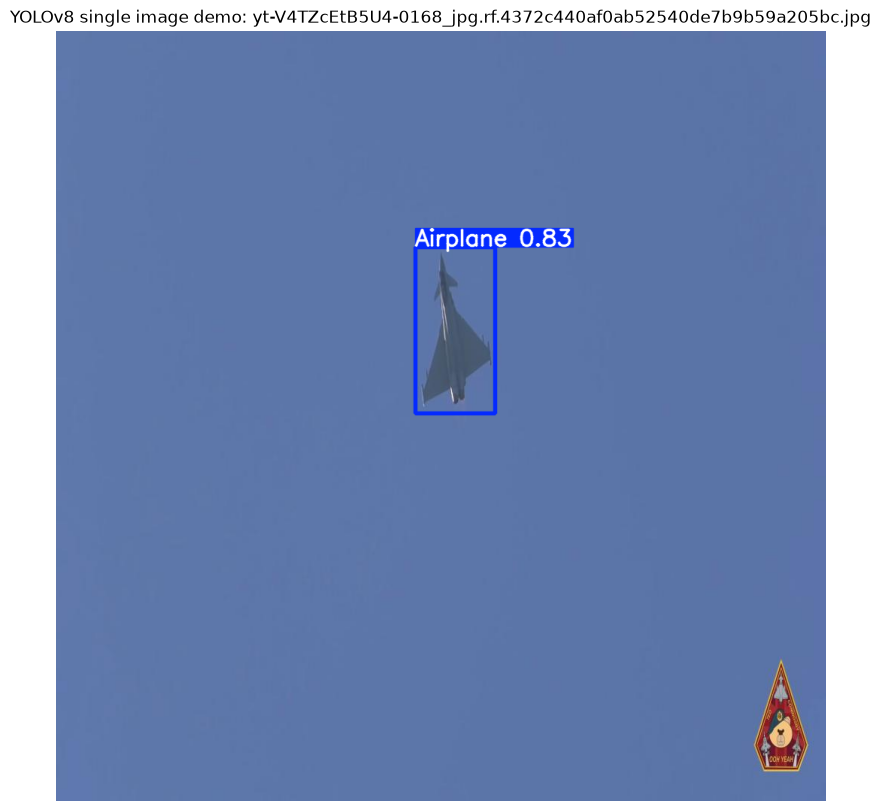

Live demo is available if you run yolo_live_demo(source=0, model=YOLO(saved_path), max_frames=300)


In [25]:
def export_to_onnx(yolo_model, export_dir='models', export_name='yolov8_export'):
    os.makedirs(export_dir, exist_ok=True)
    device = 0 if torch.cuda.is_available() else 'cpu'
    export_path = yolo_model.export(
        format='onnx',
        imgsz=640,
        simplify=True,
        dynamic=True,
        device=device,
        project=export_dir,
        name=export_name,
    )
    return export_path


def benchmark_onnx(onnx_path, dataset_path='fused_dataset/images/val', trials=100):
    imgs = sorted(glob.glob(os.path.join(dataset_path, '*.jpg')) + glob.glob(os.path.join(dataset_path, '*.png')))[:50]
    if len(imgs) == 0:
        print('No images for benchmark')
        return None
    model = YOLO(onnx_path)
    t0 = time.time()
    for i in range(trials):
        _ = model(imgs[i % len(imgs)], verbose=False)
    elapsed = time.time() - t0
    fps = trials / elapsed
    print(f'ONNX benchmark: {fps:.2f} FPS over {trials} runs')
    return fps


def yolo_image_demo(image_path, model, conf=0.25, iou=0.45):
    print('Running single-image demo for', image_path)
    results = model(image_path, conf=conf, iou=iou)
    for result in results:
        annotated = result.plot()
        plt.figure(figsize=(14, 10))
        plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f'YOLOv8 single image demo: {os.path.basename(image_path)}')
        plt.show()


def yolo_live_demo(source=0, model=None, max_frames=300, conf=0.25, iou=0.45):
    if model is None:
        raise RuntimeError('Provide a YOLO model instance for live demo')
    cap = cv2.VideoCapture(source)
    if not cap.isOpened():
        raise RuntimeError(f'Unable to open video source {source}')

    print(f'Starting live demo on source={source}. Press q to exit early.')
    frame_count = 0
    t0 = time.time()
    while frame_count < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        results = model(frame, conf=conf, iou=iou, verbose=False)
        frame = results[0].plot()
        cv2.imshow('YOLOv8 Live Demo', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
        frame_count += 1
    elapsed = time.time() - t0
    fps = frame_count / elapsed if elapsed > 0 else 0.0
    print(f'Live demo processed {frame_count} frames in {elapsed:.2f}s -> {fps:.2f} FPS')
    cap.release()
    cv2.destroyAllWindows()
    return fps


def yolo_web_demo_save_model(model):
    if model is None:
        raise RuntimeError('No YOLO model provided for save')
    export_path = model.export(format='onnx', imgsz=640, simplify=True, dynamic=True)
    return export_path


best_yolo_model = trained_models.get('yolov8s.pt', trained_models.get('yolov8n.pt', None))
if best_yolo_model is None:
    print('No trained YOLO model available for export. Run the fine-tuning cell first.')
else:
    saved_path = yolo_web_demo_save_model(best_yolo_model)
    print('Saved model to:', saved_path)
    benchmark_onnx(saved_path, dataset_path='fused_dataset/images/val', trials=100)
    val_images = sorted([f for f in os.listdir('fused_dataset/images/val') if f.lower().endswith(('.jpg', '.png'))])
    if len(val_images) > 0:
        yolo_image_demo(os.path.join('fused_dataset/images/val', val_images[7412]), YOLO(saved_path))
    else:
        print('No validation images available for single-image demo.')
    print('Live demo is available if you run yolo_live_demo(source=0, model=YOLO(saved_path), max_frames=300)')